# Model comparison and results

This notebook compares the performance and size of all CIFAR-10 models trained in previous notebooks:
- **01-DNN**: Fully connected deep neural network
- **02-CNN**: Convolutional neural network (grayscale)
- **03-RGB-CNN**: Convolutional neural network (RGB)
- **04-optimized-CNN**: Hyperparameter-optimized CNN
- **05-augmented-CNN**: CNN trained with data augmentation

## Notebook setup

### Imports

In [1]:
# Standard library imports
import json
import pickle

# Third party imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Package imports
import image_classification_tools.pytorch.plotting as plots

# Local imports
import configuration as config

### Configuration

## 1. Load saved test results

Load the test results saved from each notebook instead of re-running the models.

In [ ]:
# Load model configurations from JSON file
with open(config.MODELS_DIR / 'models_config.json', 'r') as f:
    models_metadata = json.load(f)

# Build models_config with full paths
models_config = []
for model in models_metadata['models']:
    models_config.append({
        'name': model['name'],
        'results_path': config.RESULTS_DIR / model['results_file'],
        'description': model['description'],
        'metadata': model  # Store full metadata for later use
    })

results = []

for model_config in models_config:
    
    # Check if results file exists
    if not model_config['results_path'].exists():
        
        print(f"Skipping {model_config['name']}")
        continue
    
    # Load saved results
    try:
        with open(model_config['results_path'], 'rb') as f:
            data = pickle.load(f)
        
        true_labels = np.array(data['true_labels'])
        predictions = np.array(data['predictions'])
        all_probs = np.array(data['all_probs'])
        test_accuracy = float(data['test_accuracy'])
        total_params = int(data['total_params'])
        trainable_params = int(data['trainable_params'])
        
        # Calculate model size (approximate based on parameters)
        # Assuming float32 (4 bytes per parameter)
        model_size_mb = (total_params * 4) / (1024 ** 2)
        
        # Get cold start time if available
        cold_start_time = cold_start_times.get(model_config['name'], None)
        
        # Store results
        results.append({
            'Model': model_config['name'],
            'Description': model_config['description'],
            'Total Parameters': total_params,
            'Trainable Parameters': trainable_params,
            'Size (MB)': model_size_mb,
            'Test Accuracy (%)': test_accuracy,
            'Cold Start (ms)': cold_start_time * 1000 if cold_start_time else None,
            'true_labels': true_labels,
            'predictions': predictions,
            'all_probs': all_probs
        })
        
    except Exception as e:
        print(f"Error loading results: {e}")
        continue


In [ ]:
import time
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models

# Load model configurations from JSON file
with open(config.MODELS_DIR / 'models_config.json', 'r') as f:
    models_metadata = json.load(f)

# Build model paths dictionary
models_paths = {}
for model in models_metadata['models']:
    models_paths[model['name']] = config.MODELS_DIR / model['model_file']

# Get a single test sample for cold start testing
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
test_sample_dataset = datasets.CIFAR10(root=config.DATA_DIR, train=False, transform=transform)
test_sample, _ = test_sample_dataset[0]

# RGB sample for RGB models
rgb_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
rgb_test_dataset = datasets.CIFAR10(root=config.DATA_DIR, train=False, transform=rgb_transform)
rgb_test_sample, _ = rgb_test_dataset[0]

cold_start_times = {}

for model_name, model_path in models_paths.items():
    if not model_path.exists():
        print(f"Skipping {model_name} - model file not found")
        continue
    
    # Get input type from metadata
    model_meta = next(m for m in models_metadata['models'] if m['name'] == model_name)
    input_type = model_meta.get('input_type', 'rgb')
    
    # Determine which sample to use
    if input_type == 'grayscale':
        sample = test_sample.unsqueeze(0)
    else:
        sample = rgb_test_sample.unsqueeze(0)
    
    # Measure cold start time (multiple runs for accuracy)
    times = []
    for _ in range(5):  # Run 5 times and take average
        start_time = time.time()
        
        # Load checkpoint
        checkpoint = torch.load(model_path, map_location=config.DEVICE)
        
        # Create appropriate model architecture and load weights
        if model_name == 'DNN':
            model = nn.Sequential(
                nn.Flatten(),
                nn.Dropout(0.5),
                nn.Linear(1024, 1024),
                nn.ReLU(),
                nn.Dropout(0.5),
                nn.Linear(1024, 256),
                nn.ReLU(),
                nn.Dropout(0.5),
                nn.Linear(256, 64),
                nn.ReLU(),
                nn.Dropout(0.5),
                nn.Linear(64, len(config.CLASS_NAMES))
            )
        elif model_name == 'CNN (Grayscale)':
            model = nn.Sequential(
                nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(32),
                nn.ReLU(),
                nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(32),
                nn.ReLU(),
                nn.MaxPool2d(2, 2),
                nn.Dropout(0.25),
                nn.AdaptiveAvgPool2d((1, 1)),
                nn.Flatten(),
                nn.Linear(32, 128),
                nn.ReLU(),
                nn.Dropout(0.5),
                nn.Linear(128, len(config.CLASS_NAMES))
            )
        elif model_name == 'RGB CNN':
            model = nn.Sequential(
                nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(32),
                nn.ReLU(),
                nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(32),
                nn.ReLU(),
                nn.MaxPool2d(2, 2),
                nn.Dropout(0.25),
                nn.AdaptiveAvgPool2d((1, 1)),
                nn.Flatten(),
                nn.Linear(32, 128),
                nn.ReLU(),
                nn.Dropout(0.5),
                nn.Linear(128, len(config.CLASS_NAMES))
            )
        else:  # Optimized CNN or Augmented CNN
            # These use the optimized architecture - we need to get params from checkpoint
            import image_classification_tools.pytorch.hyperparameter_optimization as optimization
            best_params = checkpoint.get('best_params')
            if best_params:
                model = optimization.create_cnn(
                    n_conv_blocks=best_params['n_conv_blocks'],
                    initial_filters=best_params['initial_filters'],
                    n_fc_layers=best_params['n_fc_layers'],
                    conv_dropout_rate=best_params['conv_dropout_rate'],
                    fc_dropout_rate=best_params['fc_dropout_rate'],
                    num_classes=len(config.CLASS_NAMES),
                    in_channels=3
                )
            else:
                print(f"Warning: {model_name} missing best_params, skipping")
                continue
        
        model.load_state_dict(checkpoint['model_state_dict'])
        model.to(config.DEVICE)
        model.eval()
        
        # Make single prediction
        with torch.no_grad():
            sample_batch = sample.to(config.DEVICE)
            _ = model(sample_batch)
        
        elapsed = time.time() - start_time
        times.append(elapsed)
        
        # Clean up
        del model
        del checkpoint
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
    
    # Average time
    avg_time = sum(times) / len(times)
    cold_start_times[model_name] = avg_time
    print(f"{model_name}: {avg_time*1000:.2f} ms (avg of {len(times)} runs)")

print("\nCold start times measured successfully!")


## 1.1. Measure cold start time for each model

Measure how long it takes to load each model from disk and make a single prediction. This is important for deployment scenarios where models need to be loaded on-demand.


## 2. Results summary

In [4]:
# Create summary dataframe
summary_df = pd.DataFrame([
    {
        'Model': r['Model'],
        'Description': r['Description'],
        'Parameters': f"{r['Total Parameters']:,}",
        'Size (MB)': f"{r['Size (MB)']:.2f}",
        'Accuracy (%)': f"{r['Test Accuracy (%)']:.2f}",
        'Cold Start (ms)': f"{r['Cold Start (ms)']:.2f}" if r['Cold Start (ms)'] else 'N/A'
    }
    for r in results
])

summary_df


,Model,Description,Parameters,Size (MB),Accuracy (%)
0,DNN,Fully connected neural network,"1,329,098",5.07,48.83
1,CNN (Grayscale),CNN on grayscale images,"15,210",0.06,62.99
2,RGB CNN,CNN on RGB images,"23,520,906",89.73,78.00
3,Optimized CNN,Hyperparameter-tuned CNN,"78,173,386",298.21,82.55
4,Augmented CNN,CNN with data augmentation,"4,889,322",18.65,76.40


## 3. Performance visualizations

### Model size vs accuracy

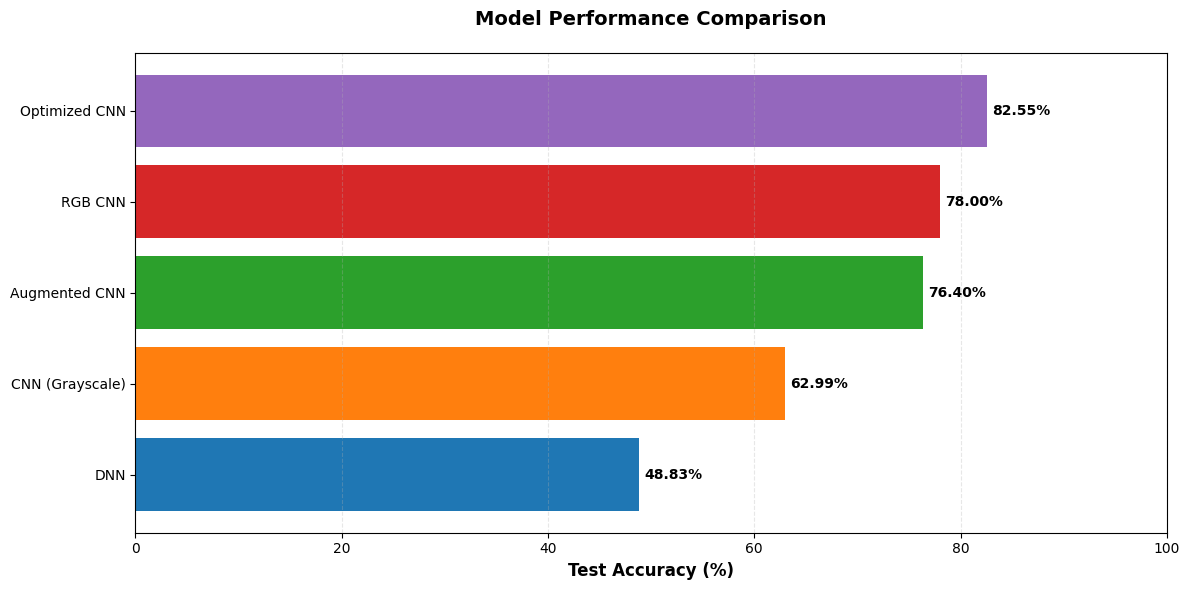

In [5]:
# Sort by accuracy for better visualization
sorted_results = sorted(results, key=lambda x: x['Test Accuracy (%)'])

# Create bar chart
fig, ax = plt.subplots(figsize=(12, 6))

models = [r['Model'] for r in sorted_results]
accuracies = [r['Test Accuracy (%)'] for r in sorted_results]

bars = ax.barh(models, accuracies, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])

# Add value labels on bars
for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    ax.text(acc + 0.5, i, f'{acc:.2f}%', va='center', fontweight='bold')

ax.set_xlabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold', pad=20)
ax.set_xlim(0, 100)
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

### Efficiency metric

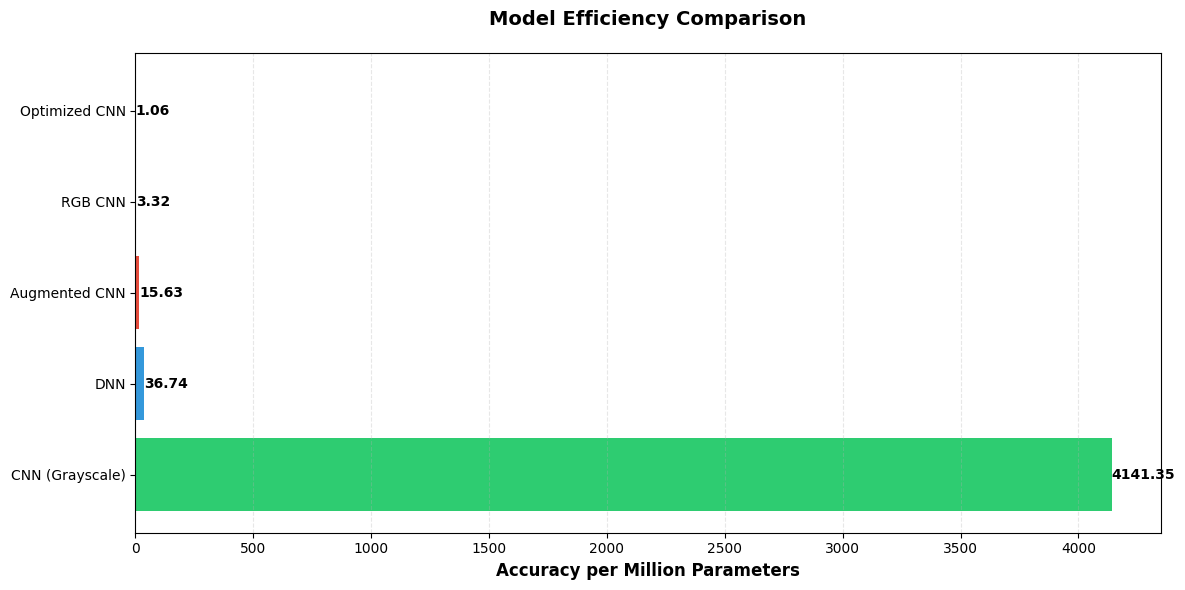


Efficiency Rankings (Accuracy per Million Parameters):
1. CNN (Grayscale): 4141.35
2. DNN: 36.74
3. Augmented CNN: 15.63
4. RGB CNN: 3.32
5. Optimized CNN: 1.06


In [6]:
# Calculate efficiency metric
efficiency_results = []
for r in results:
    params_millions = r['Total Parameters'] / 1e6
    efficiency = r['Test Accuracy (%)'] / params_millions
    efficiency_results.append({
        'Model': r['Model'],
        'Accuracy/Param (M)': efficiency
    })

# Sort by efficiency
efficiency_results = sorted(efficiency_results, key=lambda x: x['Accuracy/Param (M)'], reverse=True)

# Create bar chart
fig, ax = plt.subplots(figsize=(12, 6))

models = [r['Model'] for r in efficiency_results]
efficiencies = [r['Accuracy/Param (M)'] for r in efficiency_results]

bars = ax.barh(models, efficiencies, color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6'])

# Add value labels
for i, (bar, eff) in enumerate(zip(bars, efficiencies)):
    ax.text(eff + 0.5, i, f'{eff:.2f}', va='center', fontweight='bold')

ax.set_xlabel('Accuracy per Million Parameters', fontsize=12, fontweight='bold')
ax.set_title('Model Efficiency Comparison', fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Print efficiency table
print("\nEfficiency Rankings (Accuracy per Million Parameters):")
print("="*60)
for i, r in enumerate(efficiency_results, 1):
    print(f"{i}. {r['Model']}: {r['Accuracy/Param (M)']:.2f}")
print("="*60)

## 4. Per-class performance analysis

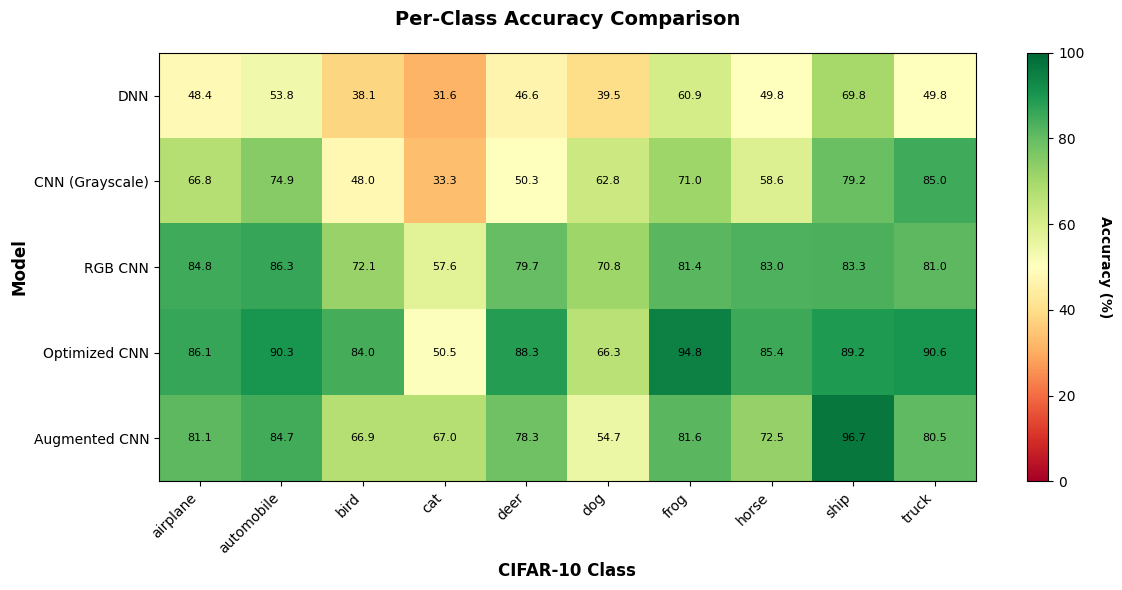


Per-Class Accuracy Summary (%):
             DNN  CNN (Grayscale)  RGB CNN  Optimized CNN  Augmented CNN
airplane    48.4             66.8     84.8           86.1           81.1
automobile  53.8             74.9     86.3           90.3           84.7
bird        38.1             48.0     72.1           84.0           66.9
cat         31.6             33.3     57.6           50.5           67.0
deer        46.6             50.3     79.7           88.3           78.3
dog         39.5             62.8     70.8           66.3           54.7
frog        60.9             71.0     81.4           94.8           81.6
horse       49.8             58.6     83.0           85.4           72.5
ship        69.8             79.2     83.3           89.2           96.7
truck       49.8             85.0     81.0           90.6           80.5


In [7]:
# Calculate per-class accuracy for each model
class_accuracies = {}

for r in results:
    
    true = r['true_labels']
    pred = r['predictions']
    
    # Calculate accuracy for each class
    class_acc = []
    for i in range(10):
        mask = (true == i)
        if mask.sum() > 0:
            acc = (pred[mask] == i).sum() / mask.sum() * 100
            class_acc.append(acc)
        else:
            class_acc.append(0)
    
    class_accuracies[r['Model']] = class_acc

# Create dataframe for better visualization
class_acc_df = pd.DataFrame(class_accuracies, index=config.CLASS_NAMES)

# Create heatmap
fig, ax = plt.subplots(figsize=(12, 6))

# Plot heatmap
im = ax.imshow(class_acc_df.T, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)

# Set ticks and labels
ax.set_xticks(np.arange(len(config.CLASS_NAMES)))
ax.set_yticks(np.arange(len(results)))
ax.set_xticklabels(config.CLASS_NAMES, rotation=45, ha='right')
ax.set_yticklabels([r['Model'] for r in results])

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Accuracy (%)', rotation=270, labelpad=20, fontweight='bold')

# Add text annotations
for i in range(len(results)):
    for j in range(len(config.CLASS_NAMES)):
        text = ax.text(j, i, f'{class_acc_df.iloc[j, i]:.1f}',
                      ha="center", va="center", color="black", fontsize=8)

ax.set_title('Per-Class Accuracy Comparison', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('CIFAR-10 Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Model', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary
print("\nPer-Class Accuracy Summary (%):")
print("="*80)
print(class_acc_df.round(1))
print("="*80)


## 5. Confusion matrix comparison

Worst Model: DNN - Accuracy: 48.83%


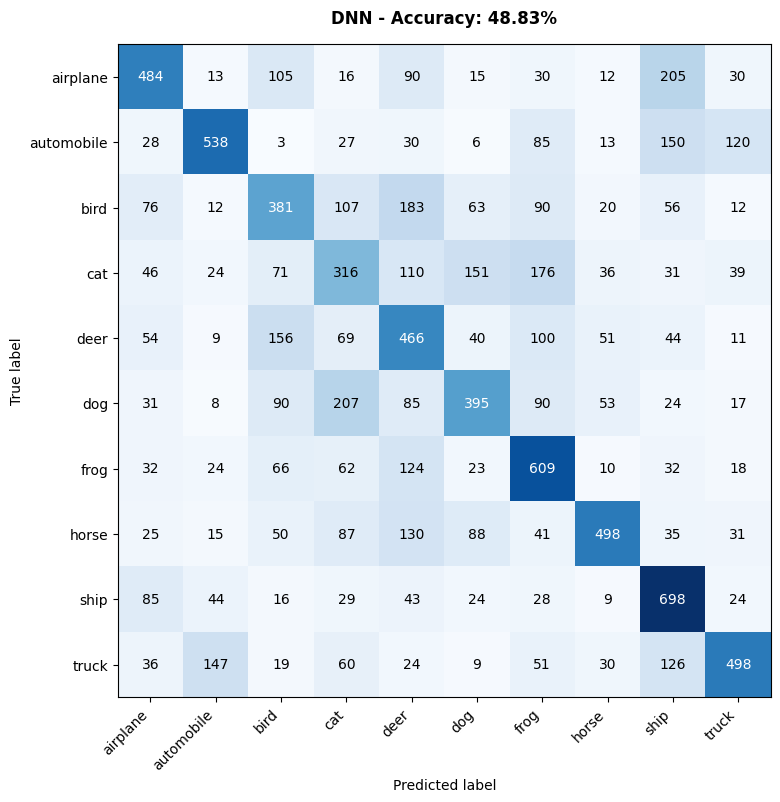


Best Model: Optimized CNN - Accuracy: 82.55%


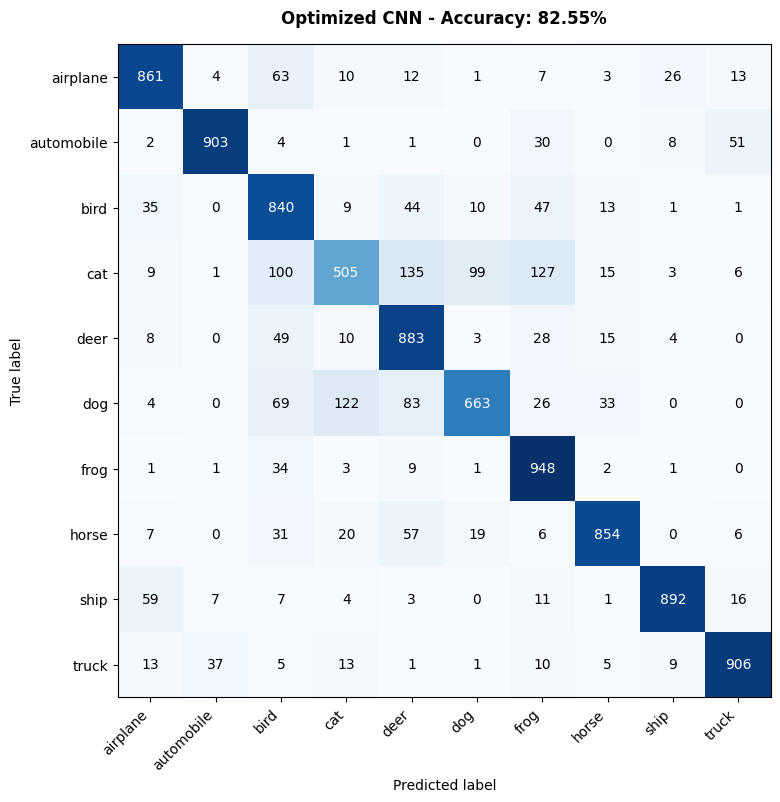

In [8]:
# Find best and worst models by accuracy
sorted_by_acc = sorted(results, key=lambda x: x['Test Accuracy (%)'])
worst_model = sorted_by_acc[0]
best_model = sorted_by_acc[-1]

# Plot confusion matrix for worst model
print(f"Worst Model: {worst_model['Model']} - Accuracy: {worst_model['Test Accuracy (%)']:.2f}%")
fig1, ax1 = plots.plot_confusion_matrix(
    worst_model['true_labels'], 
    worst_model['predictions'], 
    config.CLASS_NAMES,
    figsize=(8, 8)
)
ax1.set_title(f'{worst_model["Model"]} - Accuracy: {worst_model["Test Accuracy (%)"]:.2f}%', 
              fontsize=12, fontweight='bold', pad=15)
plt.show()

# Plot confusion matrix for best model
print(f"\nBest Model: {best_model['Model']} - Accuracy: {best_model['Test Accuracy (%)']:.2f}%")
fig2, ax2 = plots.plot_confusion_matrix(
    best_model['true_labels'], 
    best_model['predictions'], 
    config.CLASS_NAMES,
    figsize=(8, 8)
)
ax2.set_title(f'{best_model["Model"]} - Accuracy: {best_model["Test Accuracy (%)"]:.2f}%', 
              fontsize=12, fontweight='bold', pad=15)
plt.show()
